# Notebook 2: A/B Test Experiment Design
**Project:** Household-Level Coupon Experiment
**Dataset:** dunnhumby - The Complete Journey

This notebook follows the 14-step Experiment Design Plan to build a rigorous, pre-registered A/B test design for a household-level coupon campaign.

In [331]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import binomtest
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 30)

os.chdir(r"C:\Users\David Cho\OneDrive\Desktop\Projects\AB Testing\Experiment Design\The Complete Journey")

DATA_DIR = './data/'
hh = pd.read_csv(DATA_DIR + 'hh_features.csv')
print(f"Loaded household feature table: {hh.shape}")
hh.head(3)

Loaded household feature table: (2498, 50)


,household_key,total_spend,total_items,total_trips,total_days_active,total_weeks_active,n_products,n_stores,n_departments,last_purchase_day,first_purchase_day,first_purchase_week,avg_basket_value,avg_weekly_spend,avg_trips_per_week,...,n_campaigns_TypeB,n_campaigns_TypeC,n_coupons_redeemed,n_campaigns_redeemed,has_redeemed,spend_tier,recency_band,promo_tier,post_total_spend,post_total_trips,post_total_items,post_avg_weekly_spend,post_spend_per_trip,post_items_per_trip,post_active
0,1,2931.28,1370,54,48,45,497,2,13,494,51,8,2.522616,45.801250,0.843750,...,1,0,3,1,1,Medium-High,0-7d,High_Promo,1398.88,32.0,627.0,45.125161,43.715000,19.593750,1
1,2,1385.24,579,36,36,27,403,5,11,489,103,15,2.815528,24.302456,0.631579,...,0,0,0,0,0,Medium-High,0-7d,Low_Promo,569.10,9.0,255.0,18.358065,63.233333,28.333333,1
2,3,2396.90,1439,40,39,30,465,2,10,477,113,17,2.959136,43.580000,0.727273,...,0,0,0,0,0,Medium-High,8-30d,High_Promo,256.31,7.0,7101.0,8.268065,36.615714,1014.428571,1


---
## Step 1. Define the Business Decision

### Business Context

A national grocery retailer is considering launching a **targeted coupon campaign** to increase household spending. The campaign would send category-specific coupons via direct mail to selected households. Given the cost of printing, mailing, and coupon redemption (manufacturer reimbursement logistics), the retailer needs evidence that the campaign generates enough **incremental revenue** to justify rollout.

### Decision Statement

> **"Will sending a household-level promotional coupon to eligible frequent shoppers increase their incremental spending enough during a 4-week post-treatment window to justify the cost of a full-scale rollout?"**

### Why This Framing Matters

- It ties the statistical test to a **concrete business action** (launch vs. don't launch)
- It forces us to define "enough" in dollar terms (the MDE), not just statistical significance
- It prevents the common mistake of reporting "p < 0.05" without connecting to business value

---
## Step 2. Select the Eligible Population

### Eligibility Criteria

We define the eligible population as households that meet **all** of the following criteria:

| Rule | Rationale |
|---|---|
| Active in pre-period (weeks 1–71) | Must have purchase history for baseline estimation |
| At least 2 trips in pre-period | Minimum engagement to be a viable target |
| Recency ≤ 90 days from end of pre-period | Exclude likely-churned households who won't respond |
| Has received at least 1 campaign historically | Confirms contactability via direct mail channel |

**Why these rules:**
- Requiring recent activity avoids wasting coupons on churned households
- Minimum 2 trips ensures we have enough data to estimate baseline spend
- Campaign history serves as a proxy for contactability (valid mailing address)
- These rules are set **before** looking at post-period outcomes, preserving the integrity of the design

In [472]:
# ── Step 2: Apply eligibility filters ────────────────────────────────────────
print(f"Total households in pre-period: {len(hh)}")

# Filter 1: At least 2 trips
mask_trips = hh['total_trips'] >= 2
print(f"  After ≥2 trips:         {mask_trips.sum()}")

# Filter 2: Recency ≤ 90 days
mask_recency = hh['recency_days'] <= 90
print(f"  After recency ≤90d:     {(mask_trips & mask_recency).sum()}")

# Filter 3: Has received at least 1 campaign
mask_campaign = hh['n_campaigns_received'] >= 1
print(f"  After ≥1 campaign:      {(mask_trips & mask_recency & mask_campaign).sum()}")

# Apply all filters
eligible = hh[mask_trips & mask_recency & mask_campaign].copy()
print(f"\n  Eligible population: {len(eligible)} households")
print(f"  Excluded: {len(hh) - len(eligible)} households ({(len(hh) - len(eligible)) / len(hh):.1%})")

Total households in pre-period: 2498
  After ≥2 trips:         2484
  After recency ≤90d:     2320
  After ≥1 campaign:      1288

  Eligible population: 1288 households
  Excluded: 1210 households (48.4%)


---
## Step 3. Choose the Treatment, Control, and Exposure Window

### Treatment Definition

| Aspect | Description |
|---|---|
| **Treatment (T)** | Household receives a set of category-specific coupons via direct mail, targeted based on their top purchased department |
| **Control (C)** | Business-as-usual — no coupon mailing during the experiment window |
| **Channel** | Direct mail (consistent with existing campaign_table infrastructure) |
| **Coupon value** | We assume an average face value of ~$1.00 per coupon, consistent with the observed `COUPON_DISC` values in the transaction data |
| **Post-treatment window** | **4 weeks (28 days)** starting from the coupon delivery date |

### Why 4 Weeks?

- Covers at least 2 full grocery shopping cycles for most households (median trip frequency is ~1-2 trips/week)
- Short enough to limit seasonal contamination
- Long enough to capture delayed redemptions (coupons are typically valid for 30+ days per `campaign_desc`)

---
## Step 4. Define Success Metrics

### Primary Metric
**Incremental spend per eligible household** during the 4-week post-treatment window.

$$\text{Primary metric} = \bar{Y}_T - \bar{Y}_C$$

where $\bar{Y}_T$ and $\bar{Y}_C$ are the mean total household spend in the treatment and control groups during the post-period.

**Why this metric:** It directly maps to the business question ("does the coupon increase revenue?") and is continuous, enabling a standard t-test with well-understood power properties.

### Secondary Metrics
| Metric | Definition |
|---|---|
| **Conversion rate** | Proportion of eligible households making ≥1 purchase in the post-window |
| **Basket size** | Average spend per trip during post-window |
| **Trip frequency** | Number of trips per household during post-window |
| **Category penetration** | Proportion purchasing in the coupon's target category |

### Guardrail Metrics
| Guardrail | Tolerance |
|---|---|
| **Average discount cost per household** | Must not exceed $3.00 (3× face value) |
| **Margin proxy** | Net revenue (spend − discount) must remain positive |
| **Cannibalization** | Spend in non-targeted categories should not drop by more than 5% |

---
## Step 5. Build Pre-Period Baselines

In this step, we summarize pre-period **behavioral patterns** of the eligible population to *1) estimate variance for power analysis*, *2) establish baseline levels for MDE justification*, and *3) identify variables for stratified randomization*.

### 5a. Baseline Summary Statistics

In [107]:
baseline_vars = ['avg_weekly_spend', 'spend_per_trip', 'total_trips',
                 'items_per_trip', 'coupon_usage_rate', 'loyalty_usage_rate',
                 'discount_per_trip', 'n_departments', 'recency_days']

baseline_summary = eligible[baseline_vars].describe(
    percentiles=[.05, .25, .5, .75, .95]
).T
baseline_summary['IQR'] = baseline_summary['75%'] - baseline_summary['25%']
baseline_summary['skewness'] = eligible[baseline_vars].skew()
baseline_summary['kurtosis'] = eligible[baseline_vars].kurtosis()

print(f"=== Pre-Period Baseline Summary (N = {len(eligible)} eligible households) ===\n")
display(baseline_summary.round(2))

=== Pre-Period Baseline Summary (N = 1288 eligible households) ===



,count,mean,std,min,5%,25%,50%,75%,95%,max,IQR,skewness,kurtosis
avg_weekly_spend,1288.0,52.08,37.75,4.65,12.67,25.24,42.06,67.55,130.86,272.05,42.31,1.72,3.92
spend_per_trip,1288.0,34.11,20.31,2.78,10.75,19.98,29.88,43.66,72.06,177.12,23.68,1.80,5.66
total_trips,1288.0,110.32,89.27,14.00,32.00,57.75,86.50,131.25,275.30,979.00,73.50,3.32,18.58
items_per_trip,1288.0,830.50,1241.69,1.87,7.15,17.17,218.71,1173.40,3431.63,9989.08,1156.23,2.15,5.67
coupon_usage_rate,1288.0,0.01,0.02,0.00,0.00,0.00,0.00,0.01,0.05,0.24,0.01,4.20,25.22
loyalty_usage_rate,1288.0,0.49,0.09,0.22,0.35,0.43,0.49,0.55,0.65,0.88,0.12,0.23,0.32
discount_per_trip,1288.0,6.25,4.30,0.37,1.72,3.44,5.36,7.91,13.60,65.00,4.46,3.39,30.25
n_departments,1288.0,13.69,3.06,4.00,9.00,11.00,14.00,16.00,19.00,23.00,5.00,0.07,-0.28
recency_days,1288.0,7.32,12.19,0.00,0.00,1.00,3.00,8.00,29.00,90.00,7.00,3.27,12.69


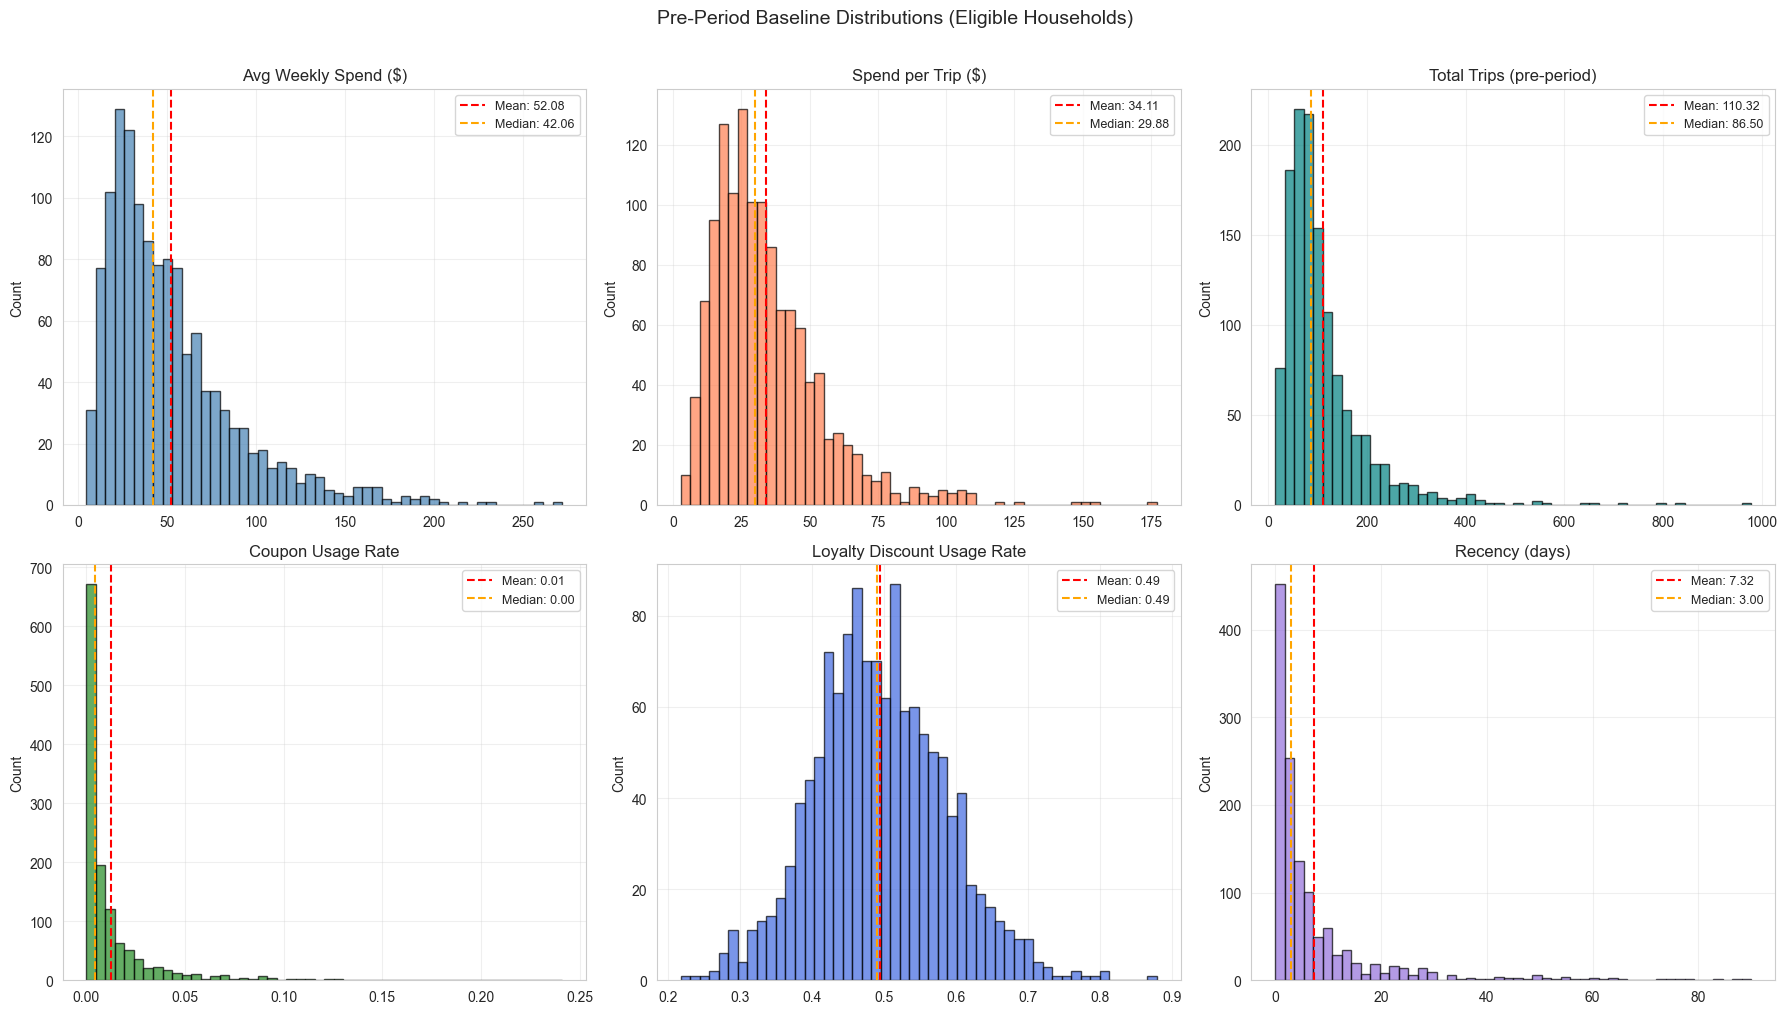

In [108]:
# Baseline distributions of key metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = {
    'avg_weekly_spend': ('Avg Weekly Spend ($)', 'steelblue'),
    'spend_per_trip': ('Spend per Trip ($)', 'coral'),
    'total_trips': ('Total Trips (pre-period)', 'teal'),
    'coupon_usage_rate': ('Coupon Usage Rate', 'forestgreen'),
    'loyalty_usage_rate':('Loyalty Discount Usage Rate', 'royalblue'),
    'recency_days': ('Recency (days)', 'mediumpurple'),
}

for ax, (col, (title, color)) in zip(axes.flatten(), metrics.items()):
    data = eligible[col].dropna()
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color=color)
    ax.axvline(data.mean(), color='red', ls='--', lw=1.5,
               label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', ls='--', lw=1.5,
               label=f'Median: {data.median():.2f}')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Pre-Period Baseline Distributions (Eligible Households)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

=== Baseline by Spend Tier ===


avg_weekly_spend              total_trips                \
                        mean    std count        mean     std count   
spend_tier                                                            
Low                     7.23   1.45    23       47.04   18.68    23   
Medium-Low             16.91   3.82   234       59.99   38.33   234   
Medium-High            33.35   6.82   458       83.36   45.72   458   
High                   83.22  36.39   573      154.97  108.97   573   

            coupon_usage_rate             recency_days               
                         mean   std count         mean    std count  
spend_tier                                                           
Low                      0.02  0.03    23        20.52  20.13    23  
Medium-Low               0.01  0.02   234        12.44  16.10   234  
Medium-High              0.01  0.02   458         7.90  12.31   458  
High                     0.02  0.02   573         4.23   8.03   573

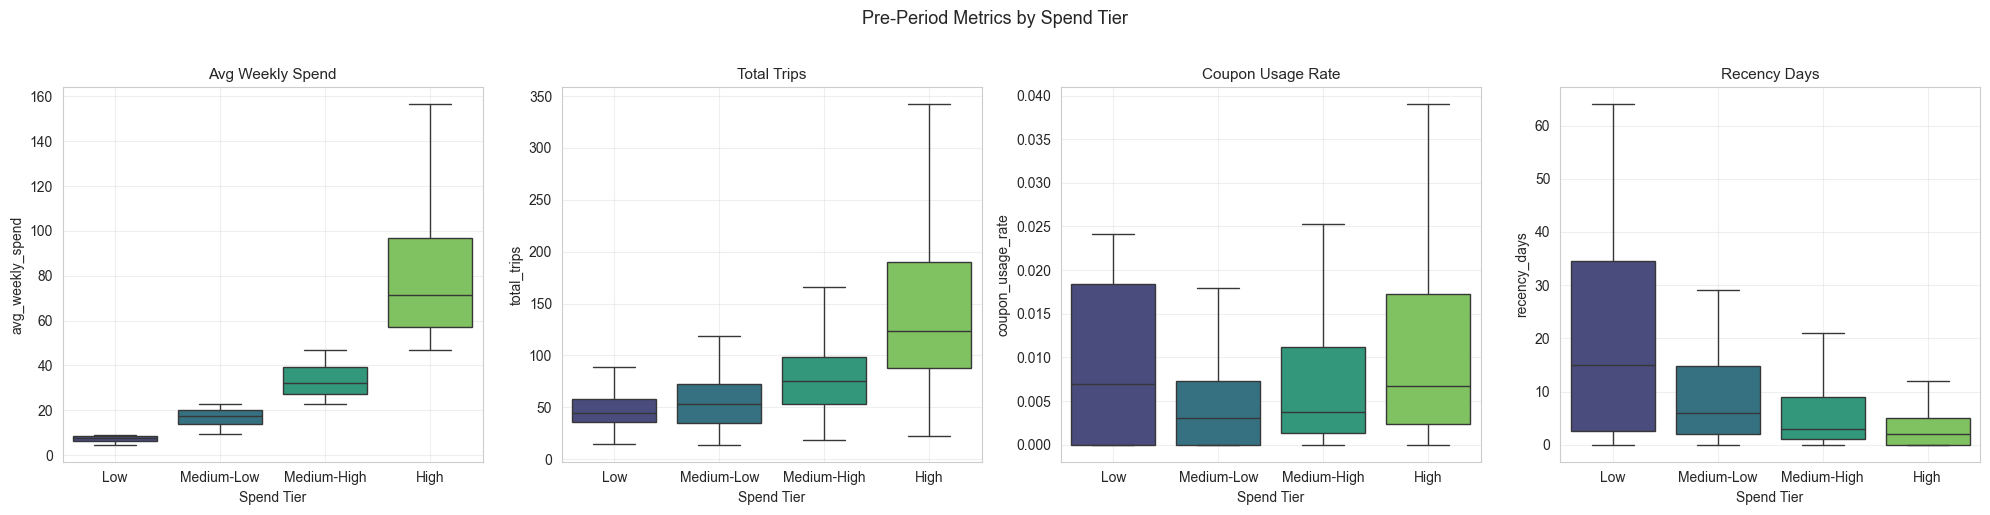

In [109]:
# Baseline by spend tier (stratification sanity check)
strat_vars = ['avg_weekly_spend', 'total_trips', 'coupon_usage_rate', 'recency_days']
strat_baseline = (eligible.groupby('spend_tier')[strat_vars]
                  .agg(['mean', 'std', 'count']))

tier_order = ['Low', 'Medium-Low', 'Medium-High', 'High']

print("=== Baseline by Spend Tier ===")
display(strat_baseline.reindex(tier_order).round(2))

# Visualize tier differences
fig, axes = plt.subplots(1, 4, figsize=(20, 5))


for ax, col in zip(axes, strat_vars):
    sns.boxplot(data=eligible, x='spend_tier', y=col, order=tier_order, ax=ax,
                palette='viridis', showfliers=False)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Spend Tier')
    ax.grid(True, alpha=0.3)

plt.suptitle('Pre-Period Metrics by Spend Tier', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5a Interpretation

- **Spend distribution:** The distribution of `avg_weekly_spend` is right-skewed, winsorization may be necessary. Using raw values directly in power analysis could lead to overestimation.  
- **Effectiveness of stratification:** Baseline characteristics differ significantly across `spend_tier`. Stratified randomization can help ensure better balance between treatment and control groups.  
- **Coupon responsiveness:** Overall coupon usage rate is low. The treatment effect may be concentrated within specific subsets, indicating the need to consider heterogeneous treatment effects.

---

### 5b. Variance Estimation & Post-Period Metric Validation

The key input for power analysis is the **standard deviation (σ) of the outcome**. If we directly use the σ of `avg_weekly_spend` from the pre-period, the 71-week aggregation may fail to capture the noise present in a realistic 4-week experiment window.

Therefore, we use post-period data as a proxy for a future experiment:
- Since no treatment is applied in the post-period, we can measure pure natural variability  
- We segment the data into 4-week rolling windows to match the granularity of the actual experiment duration  
- We estimate the effective variance as:  

$$\sigma_{\text{power}} = \max\left(\sigma_{\text{pre scaled}},\; \text{median}(\sigma_{\text{post 4wk windows}})\right)$$

This conservative approach helps prevent the power analysis from being overly optimistic.

#### 5b-1) Average Weekly Spend

=== Pre-Period Avg Weekly Spend (Outcome Proxy) ===
  Raw:        mean=$52.08,  σ=37.75,  skew=1.72
  Winsorized: mean=$51.82,  σ=36.56,  skew=1.48

=== Post-Period Avg Weekly Spend (Outcome) ===
  Raw:        mean=$51.10,  σ=42.33,  skew=1.55
  Winsorized: mean=$50.89,  σ=41.48,  skew=1.42


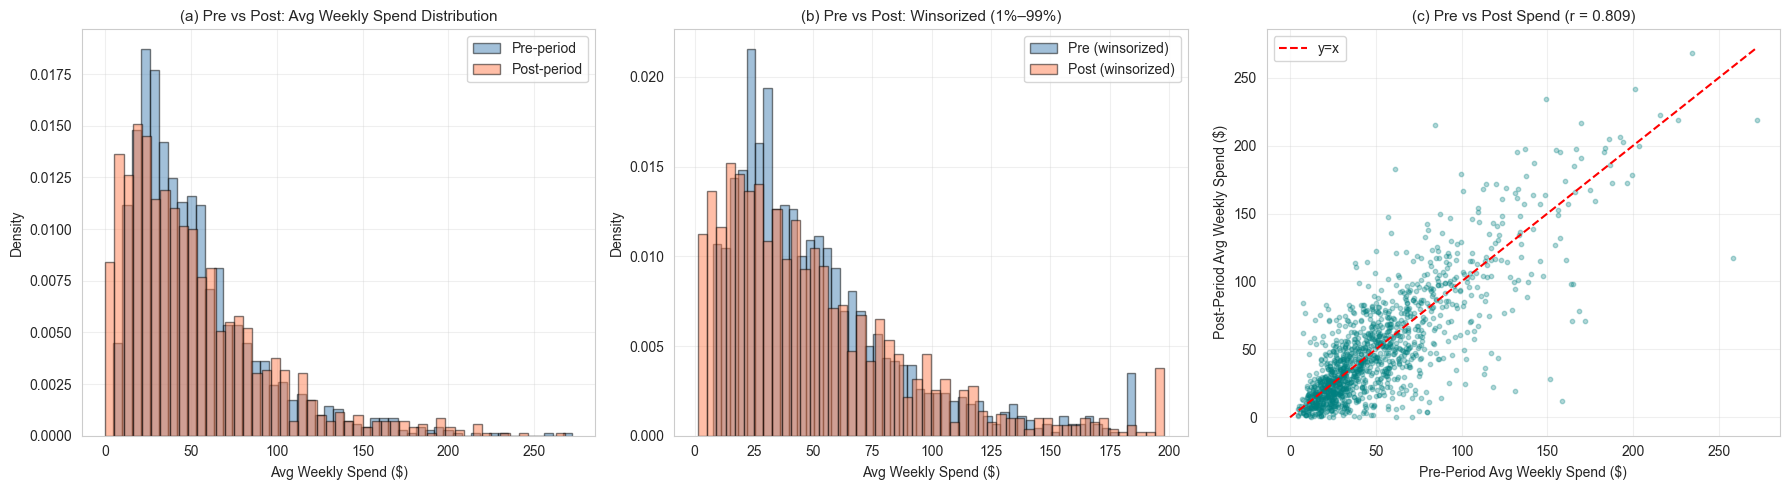


Pre-Post correlation: r = 0.809  (Key indicator for assessing variance reduction potential in CUPED)


In [112]:
# Variance estimation — Pre-period
# Raw and winsorized outcome from pre-period
pre_outcome = eligible['avg_weekly_spend']
pre_winsorized = pre_outcome.clip(
    lower=pre_outcome.quantile(0.01),
    upper=pre_outcome.quantile(0.99)
)

print("=== Pre-Period Avg Weekly Spend (Outcome Proxy) ===")
print(f"  Raw:        mean=${pre_outcome.mean():.2f},  σ={pre_outcome.std():.2f},  skew={pre_outcome.skew():.2f}")
print(f"  Winsorized: mean=${pre_winsorized.mean():.2f},  σ={pre_winsorized.std():.2f},  skew={pre_winsorized.skew():.2f}")

# Post-period outcome (already in hh_features)
post_outcome = eligible['post_avg_weekly_spend']
post_winsorized = post_outcome.clip(
    lower=post_outcome.quantile(0.01),
    upper=post_outcome.quantile(0.99)
)

print(f"\n=== Post-Period Avg Weekly Spend (Outcome) ===")
print(f"  Raw:        mean=${post_outcome.mean():.2f},  σ={post_outcome.std():.2f},  skew={post_outcome.skew():.2f}")
print(f"  Winsorized: mean=${post_winsorized.mean():.2f},  σ={post_winsorized.std():.2f},  skew={post_winsorized.skew():.2f}")

# Side-by-side distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Pre vs Post raw distributions
ax = axes[0]
ax.hist(pre_outcome, bins=50, alpha=0.5, color='steelblue', edgecolor='black', label='Pre-period', density=True)
ax.hist(post_outcome, bins=50, alpha=0.5, color='coral', edgecolor='black', label='Post-period', density=True)
ax.set_title('(a) Pre vs Post: Avg Weekly Spend Distribution', fontsize=11)
ax.set_xlabel('Avg Weekly Spend ($)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Pre vs Post winsorized
ax = axes[1]
ax.hist(pre_winsorized, bins=50, alpha=0.5, color='steelblue', edgecolor='black', label='Pre (winsorized)', density=True)
ax.hist(post_winsorized, bins=50, alpha=0.5, color='coral', edgecolor='black', label='Post (winsorized)', density=True)
ax.set_title('(b) Pre vs Post: Winsorized (1%–99%)', fontsize=11)
ax.set_xlabel('Avg Weekly Spend ($)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Scatter: pre vs post spend (correlation check)
ax = axes[2]
ax.scatter(pre_outcome, post_outcome, alpha=0.3, s=10, color='teal')
corr = pre_outcome.corr(post_outcome)
ax.plot([0, pre_outcome.max()], [0, pre_outcome.max()], 'r--', lw=1.5, label='y=x')
ax.set_title(f'(c) Pre vs Post Spend (r = {corr:.3f})', fontsize=11)
ax.set_xlabel('Pre-Period Avg Weekly Spend ($)')
ax.set_ylabel('Post-Period Avg Weekly Spend ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPre-Post correlation: r = {corr:.3f}  (Key indicator for assessing variance reduction potential in CUPED)")

#### 5b-2) 4 Week Rolling Window Analysis

In [478]:
# Post-period as proxy for the future experiment — same 4-week granularity
txn_all = pd.read_csv(DATA_DIR + 'transaction_data.csv')
POST_START, POST_END = 72, 102
WINDOW_SIZE = 4

txn_post_raw = txn_all[txn_all['WEEK_NO'].between(POST_START, POST_END)].copy()
eligible_keys = set(eligible['household_key'])

# Weekly household-level aggregation
weekly_hh = (txn_post_raw[txn_post_raw['household_key'].isin(eligible_keys)]
             .groupby(['household_key', 'WEEK_NO'])
             .agg(weekly_spend=('SALES_VALUE', 'sum'),
                  weekly_trips=('BASKET_ID', 'nunique'))
             .reset_index())

post_weeks = sorted(weekly_hh['WEEK_NO'].unique())

# Rolling 4-week window statistics
window_stats = []
for si in range(len(post_weeks) - WINDOW_SIZE + 1):
    ws, we = post_weeks[si], post_weeks[si + WINDOW_SIZE - 1]
    win = weekly_hh[weekly_hh['WEEK_NO'].between(ws, we)]
    hh_agg = win.groupby('household_key')['weekly_spend'].sum()

    # Full ITT population: include zero-spend eligible households
    full = pd.Series(0.0, index=list(eligible_keys))
    full.update(hh_agg)

    n_active = len(hh_agg)
    n_eligible = len(eligible_keys)

    window_stats.append({
        'window': f'W{ws}-{we}', 'w_start': ws,
        # --- All eligible (ITT, with zeros) ---
        'mean_spend_all':    full.mean(),
        'std_spend_all':     full.std(),
        'cv_all':            full.std() / full.mean() if full.mean() > 0 else np.nan,
        'skew_all':          full.skew(),
        # --- Active shoppers only ---
        'mean_spend_active': hh_agg.mean(),
        'std_spend_active':  hh_agg.std(),
        'cv_active':         hh_agg.std() / hh_agg.mean(),
        'skew_active':       hh_agg.skew(),
        # --- Conversion ---
        'n_active':          n_active,
        'conversion_rate':   n_active / n_eligible,
    })

wdf = pd.DataFrame(window_stats)

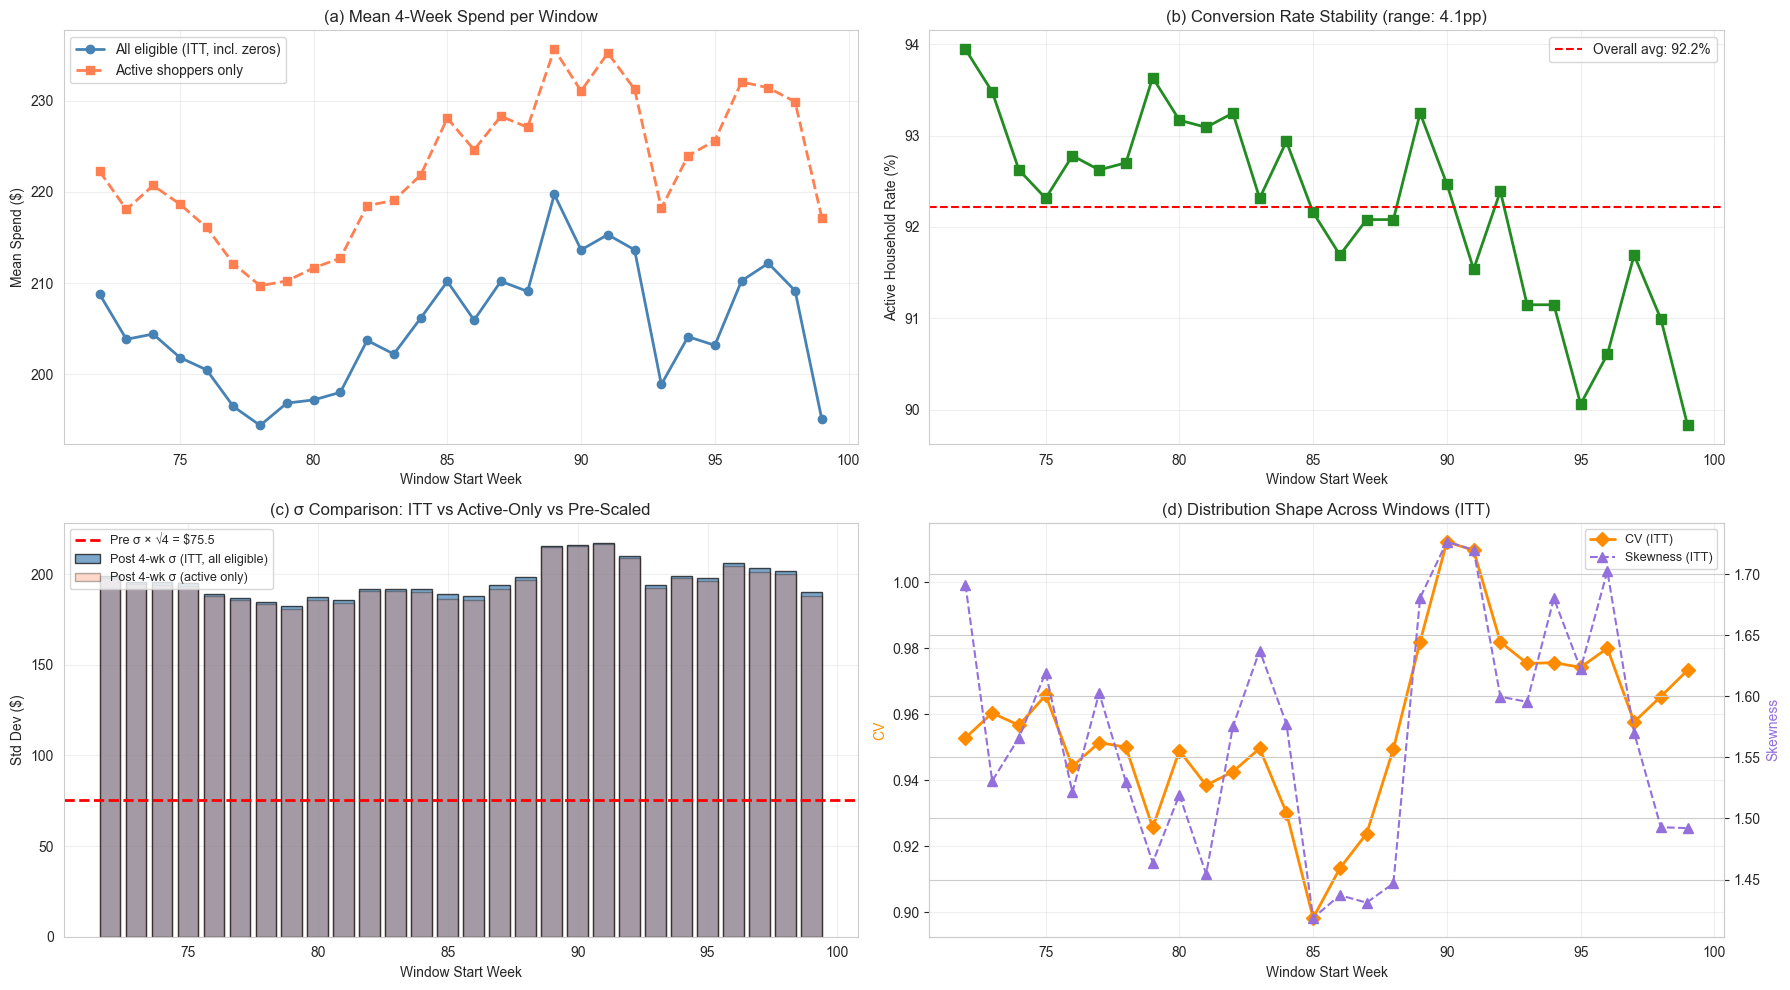

=== 4-Week Rolling Window Summary ===
  Windows analyzed:         28

  --- ITT (all eligible, zeros included) ---
  Mean spend range:         $194.40 – $219.71
  Std dev range:            182.23 – 217.39
  Median σ (ITT):          $194.57

  --- Active shoppers only ---
  Mean spend range:         $209.71 – $235.62
  Std dev range:            180.70 – 216.67
  Median σ (active):       $193.10

  --- Comparison ---
  Pre-period σ (scaled):   $75.51
  Conversion rate range:    89.8% – 93.9%


In [482]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# (a) Mean spend trend — all eligible (ITT) vs active only
ax = axes[0, 0]
ax.plot(wdf['w_start'], wdf['mean_spend_all'], 'o-', color='steelblue', lw=2, label='All eligible (ITT, incl. zeros)')
ax.plot(wdf['w_start'], wdf['mean_spend_active'], 's--', color='coral', lw=2, label='Active shoppers only')
ax.set_title('(a) Mean 4-Week Spend per Window', fontsize=12)
ax.set_xlabel('Window Start Week')
ax.set_ylabel('Mean Spend ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Conversion rate stability
ax = axes[0, 1]
ax.plot(wdf['w_start'], wdf['conversion_rate'] * 100, 's-', color='forestgreen', lw=2, ms=7)
overall_conv = wdf['conversion_rate'].mean() * 100
ax.axhline(overall_conv, color='red', ls='--', lw=1.5, label=f'Overall avg: {overall_conv:.1f}%')
conv_range = wdf['conversion_rate'].max() * 100 - wdf['conversion_rate'].min() * 100
ax.set_title(f'(b) Conversion Rate Stability (range: {conv_range:.1f}pp)', fontsize=12)
ax.set_xlabel('Window Start Week')
ax.set_ylabel('Active Household Rate (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# (c) σ comparison: ITT (all eligible) vs pre-period scaled
ax = axes[1, 0]
EXPERIMENT_WEEKS = 4
pre_sigma_scaled = eligible['avg_weekly_spend'].std() * np.sqrt(EXPERIMENT_WEEKS)
ax.bar(wdf['w_start'], wdf['std_spend_all'], color='steelblue',
       edgecolor='black', alpha=0.7, label='Post 4-wk σ (ITT, all eligible)')
ax.bar(wdf['w_start'], wdf['std_spend_active'], color='coral',
       edgecolor='black', alpha=0.3, label='Post 4-wk σ (active only)')
ax.axhline(pre_sigma_scaled, color='red', ls='--', lw=2,
           label=f'Pre σ × √4 = ${pre_sigma_scaled:.1f}')
ax.set_title('(c) σ Comparison: ITT vs Active-Only vs Pre-Scaled', fontsize=12)
ax.set_xlabel('Window Start Week')
ax.set_ylabel('Std Dev ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (d) CV & Skewness per window (ITT population)
ax = axes[1, 1]
ax.plot(wdf['w_start'], wdf['cv_all'], 'D-', color='darkorange', lw=2, ms=7, label='CV (ITT)')
ax2 = ax.twinx()
ax2.plot(wdf['w_start'], wdf['skew_all'], '^--', color='mediumpurple', lw=1.5, ms=7, label='Skewness (ITT)')
ax.set_title('(d) Distribution Shape Across Windows (ITT)', fontsize=12)
ax.set_xlabel('Window Start Week')
ax.set_ylabel('CV', color='darkorange')
ax2.set_ylabel('Skewness', color='mediumpurple')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
print("=== 4-Week Rolling Window Summary ===")
print(f"  Windows analyzed:         {len(wdf)}")
print(f"\n  --- ITT (all eligible, zeros included) ---")
print(f"  Mean spend range:         ${wdf['mean_spend_all'].min():.2f} – ${wdf['mean_spend_all'].max():.2f}")
print(f"  Std dev range:            {wdf['std_spend_all'].min():.2f} – {wdf['std_spend_all'].max():.2f}")
print(f"  Median σ (ITT):          ${wdf['std_spend_all'].median():.2f}")
print(f"\n  --- Active shoppers only ---")
print(f"  Mean spend range:         ${wdf['mean_spend_active'].min():.2f} – ${wdf['mean_spend_active'].max():.2f}")
print(f"  Std dev range:            {wdf['std_spend_active'].min():.2f} – {wdf['std_spend_active'].max():.2f}")
print(f"  Median σ (active):       ${wdf['std_spend_active'].median():.2f}")
print(f"\n  --- Comparison ---")
print(f"  Pre-period σ (scaled):   ${pre_sigma_scaled:.2f}")
print(f"  Conversion rate range:    {wdf['conversion_rate'].min():.1%} – {wdf['conversion_rate'].max():.1%}")


### 5b Interpretation: Metric Behavior & Variance

**1. Pre vs Post Consistency:**
   - Pre- and post-period spend distributions are similar in shape and center, with persistent right-skewness.  
   - The strong correlation (r ≈ 0.81) indicates that pre-period behavior is predictive of outcomes, supporting the use of CUPED.

**2. Metric Stability (4-week window):**
  - Plot (a)-(b): Average spend and conversion rate seem stable across rolling 4-week windows, with no strong trend or seasonality.  
→ 4-week experiment window is appropriate.

**3. Variance Assessment:**
  - Plot (c): Post-period 4-week variance is consistently higher than pre-period estimates.  
→ Pre-only variance leads to overly optimistic power analysis.  
→ Use a conservative estimate based on post-period variability.

**4. Distribution Shape**
  - Plot (d): Spend is right-skewed with stable but relatively high CV (~0.85–0.93).  
→ Winsorization or transformation is recommended.

### Key Takeaway
Pre-period provides a reliable baseline, but short-term variability is higher than expected.  
Accurate experiment design requires incorporating post-period variance and accounting for skewness.

---

### 5c. Metric Feasibility & MDE Realism Check

Before proceeding to power analysis, we perform two final checks:

1. **Metric feasibility:** Ensure that spend data within a 4-week window is not too sparse (e.g., zero-inflation) and not excessively noisy (e.g., heavy-tailed distribution)
2. **MDE realism:** Using empirically observed noise from the post-period, assess whether the target MDE is realistically detectable

To support this, we select a representative 4-week window from the post-period and conduct an A/A simulation.

#### 5c-1) Metric Feasibility - Sparsity & Distribution Diagnostics

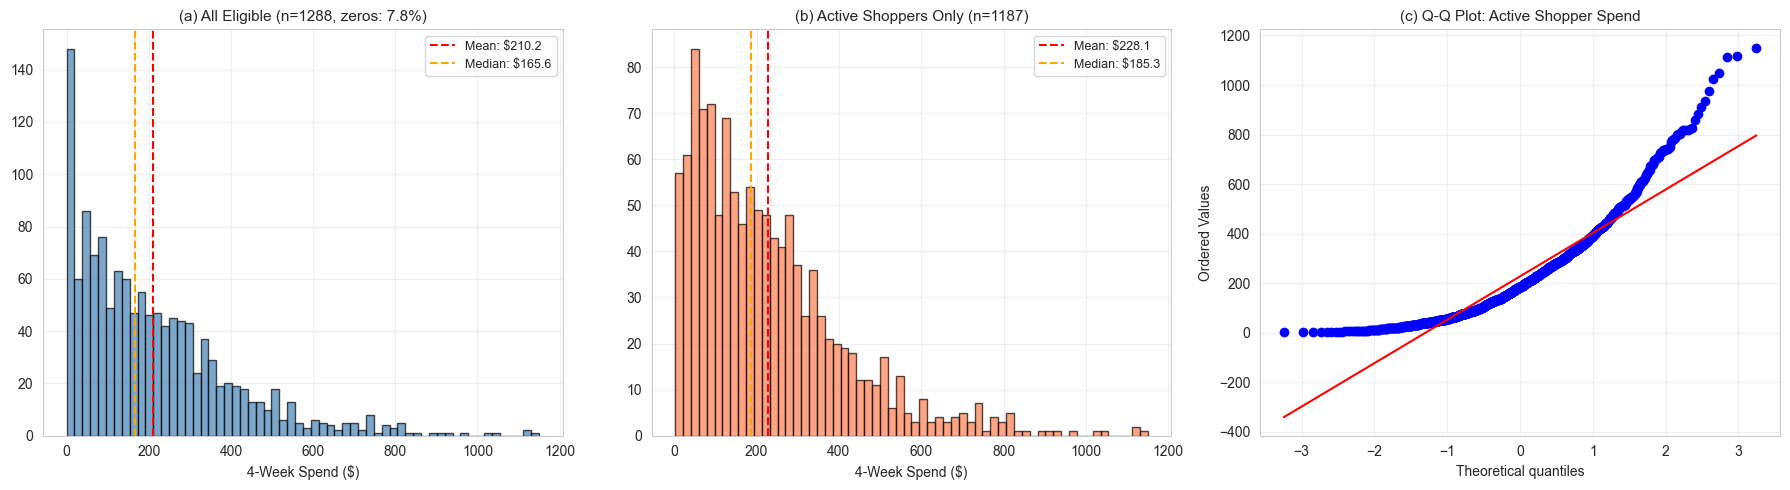

=== Metric Feasibility (Week 85–88) ===
  Eligible households:     1288
  Active (spend > 0):      1187 (92.2%)
  Zero-spend (inactive):   101 (7.8%)
  Mean (all / active):     $210.17 / $228.06
  Std  (all / active):     188.81 / 186.02
  Skewness (all / active): 1.42 / 1.44
  Kurtosis (all / active): 2.56 / 2.65

  Low sparsity (8% zeros)
  Strong right skew (1.42)


In [214]:
# Select a representative 4-week window from the middle of post-period
mid_idx = len(post_weeks) // 2
ws_mid, we_mid = post_weeks[mid_idx - 2], post_weeks[mid_idx + 1]

mask = weekly_hh['WEEK_NO'].between(ws_mid, we_mid)
sample_agg = weekly_hh[mask].groupby('household_key')['weekly_spend'].sum()

# Full population including zero-spend households
full_spend = pd.Series(0.0, index=list(eligible_keys), name='spend_4wk')
full_spend.update(sample_agg)

pct_zero = (full_spend == 0).mean() * 100
active_spend = full_spend[full_spend > 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Full distribution including zeros
ax = axes[0]
ax.hist(full_spend, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(full_spend.mean(), color='red', ls='--', label=f'Mean: ${full_spend.mean():.1f}')
ax.axvline(full_spend.median(), color='orange', ls='--', label=f'Median: ${full_spend.median():.1f}')
ax.set_title(f'(a) All Eligible (n={len(full_spend)}, zeros: {pct_zero:.1f}%)', fontsize=11)
ax.set_xlabel('4-Week Spend ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) Active shoppers only
ax = axes[1]
ax.hist(active_spend, bins=60, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(active_spend.mean(), color='red', ls='--', label=f'Mean: ${active_spend.mean():.1f}')
ax.axvline(active_spend.median(), color='orange', ls='--', label=f'Median: ${active_spend.median():.1f}')
ax.set_title(f'(b) Active Shoppers Only (n={len(active_spend)})', fontsize=11)
ax.set_xlabel('4-Week Spend ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (c) QQ-plot
ax = axes[2]
from scipy.stats import probplot
probplot(active_spend, dist='norm', plot=ax)
ax.set_title('(c) Q-Q Plot: Active Shopper Spend', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sparsity summary
print(f"=== Metric Feasibility (Week {ws_mid}–{we_mid}) ===")
print(f"  Eligible households:     {len(full_spend)}")
print(f"  Active (spend > 0):      {len(active_spend)} ({len(active_spend)/len(full_spend):.1%})")
print(f"  Zero-spend (inactive):   {(full_spend == 0).sum()} ({pct_zero:.1f}%)")
print(f"  Mean (all / active):     ${full_spend.mean():.2f} / ${active_spend.mean():.2f}")
print(f"  Std  (all / active):     {full_spend.std():.2f} / {active_spend.std():.2f}")
print(f"  Skewness (all / active): {full_spend.skew():.2f} / {active_spend.skew():.2f}")
print(f"  Kurtosis (all / active): {full_spend.kurtosis():.2f} / {active_spend.kurtosis():.2f}")

if pct_zero > 30:
    print(f"\n  High sparsity ({pct_zero:.0f}% zeros) — consider conditional metric or restricting to active-only population")
elif pct_zero > 10:
    print(f"\n  Moderate sparsity ({pct_zero:.0f}% zeros) — winsorization recommended; consider both ITT and active-only analyses")
else:
    print(f"\n  Low sparsity ({pct_zero:.0f}% zeros)")
    print(f"  Strong right skew ({full_spend.skew():.2f})")

#### 5c-2) MDE Realism Check via A/A Simulation

**A/A Simulation**: Randomly split the post-period data into two groups (no treatment) and observe the distribution of mean differences. This is the "noise floor." If our target MDE is within this noise, the experiment cannot detect it.

=== Variance & MDE Comparison (ITT Population) ===
  Pre-period σ (weekly):         37.75
  Pre-period σ (scaled to 4wk):  75.51
  Post-period σ (4wk, ITT):      194.57
  Post-period σ (4wk, active):   193.10  (for reference only)
  Ratio (post ITT / pre):        2.58
  N per arm:                     644

  Power    MDE (pre σ)    MDE (post σ)    Diff     % of μ  
  -------------------------------------------------------
  80%      $11.79          $30.38           $18.59    14.9%
  90%      $13.64          $35.15           $21.51    17.2%



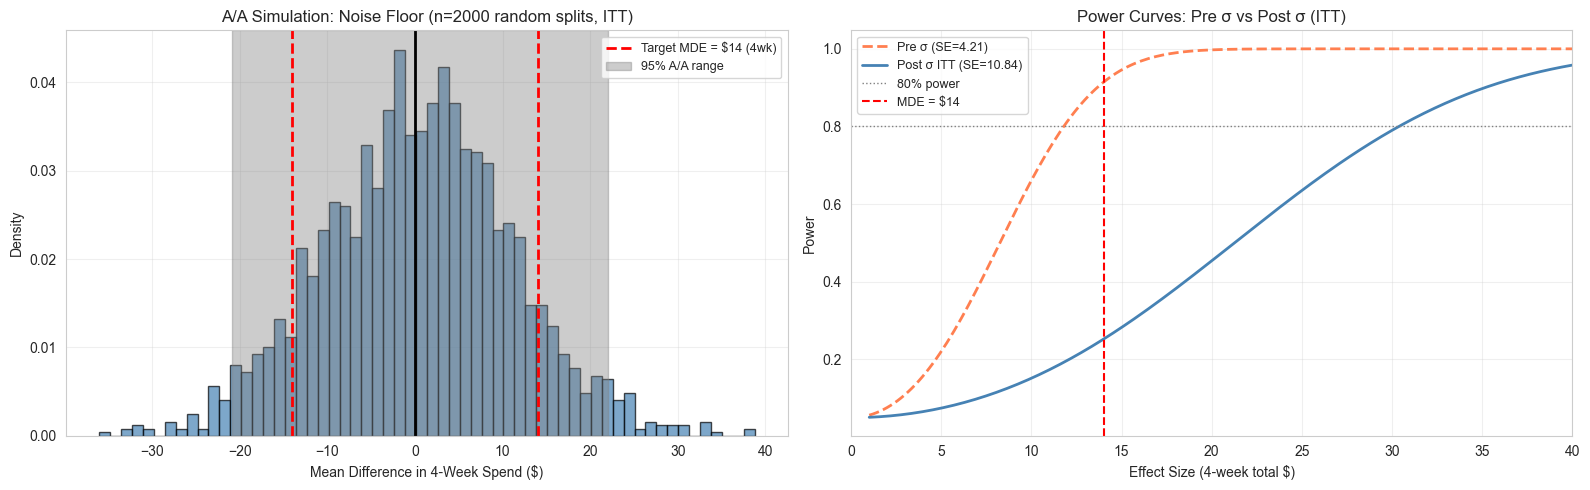


=== A/A Simulation Results (ITT Population) ===
  Simulated SE:          10.81
  Theoretical SE (post): 10.84
  Mean of diffs:         $0.346 (should ≈ 0)
  95% A/A interval:      [$-20.86, $22.03]
  Target MDE (4wk):      $14.00
  False positive at MDE: 18.8%
  MDE detectable?        No — MDE is within A/A noise, consider increasing MDE or using CUPED

  → σ for power analysis: $194.57 (conservative: max of pre and post, ITT-based)


In [500]:
sigma_4wk_post = wdf['std_spend_all'].median()  # ITT: all eligible, zeros included
n_per_arm = len(eligible) // 2
alpha = 0.05
z_alpha = stats.norm.ppf(1 - alpha / 2)

# Pre vs Post σ comparison table
print("=== Variance & MDE Comparison (ITT Population) ===")
print(f"  Pre-period σ (weekly):         {eligible['avg_weekly_spend'].std():.2f}")
print(f"  Pre-period σ (scaled to 4wk):  {pre_sigma_scaled:.2f}")
print(f"  Post-period σ (4wk, ITT):      {sigma_4wk_post:.2f}")
print(f"  Post-period σ (4wk, active):   {wdf['std_spend_active'].median():.2f}  (for reference only)")
ratio = sigma_4wk_post / pre_sigma_scaled
print(f"  Ratio (post ITT / pre):        {ratio:.2f}")
print(f"  N per arm:                     {n_per_arm}")
print()

# Compute MDE at different power levels for both estimates
print(f"  {'Power':<8} {'MDE (pre σ)':<14} {'MDE (post σ)':<15} {'Diff':<8} {'% of μ':<8}")
print("  " + "-" * 55)
sigma_for_power = max(pre_sigma_scaled, sigma_4wk_post)
for pwr in [0.80, 0.90]:
    zb = stats.norm.ppf(pwr)
    mde_pre  = (z_alpha + zb) * pre_sigma_scaled * np.sqrt(2 / n_per_arm)
    mde_post = (z_alpha + zb) * sigma_4wk_post * np.sqrt(2 / n_per_arm)
    delta = mde_post - mde_pre
    pct_mu = mde_post / wdf['mean_spend_all'].median() * 100
    print(f"  {pwr:<8.0%} ${mde_pre:<14.2f} ${mde_post:<15.2f} ${delta:<8.2f} {pct_mu:<4.1f}%")
print()

# A/A Simulation
N_SIM = 2000
np.random.seed(42)
aa_diffs = np.empty(N_SIM)

for i in range(N_SIM):
    perm = np.random.permutation(len(full_spend))
    grp_a = full_spend.iloc[perm[:n_per_arm]]
    grp_b = full_spend.iloc[perm[n_per_arm:2*n_per_arm]]
    aa_diffs[i] = grp_a.mean() - grp_b.mean()

# Visualization
target_mde_weekly = 3.50
target_mde_4wk = target_mde_weekly * WINDOW_SIZE

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) A/A distribution with MDE markers
ax = axes[0]
ax.hist(aa_diffs, bins=60, edgecolor='black', alpha=0.7, color='steelblue', density=True)
ax.axvline(0, color='black', lw=2)
ax.axvline(target_mde_4wk, color='red', ls='--', lw=2,
           label=f'Target MDE = ${target_mde_4wk:.0f} (4wk)')
ax.axvline(-target_mde_4wk, color='red', ls='--', lw=2)
ci95 = np.percentile(aa_diffs, [2.5, 97.5])
ax.axvspan(ci95[0], ci95[1], alpha=0.4, color='gray', label='95% A/A range')
ax.set_title('A/A Simulation: Noise Floor (n=2000 random splits, ITT)', fontsize=12)
ax.set_xlabel('Mean Difference in 4-Week Spend ($)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) Power curves: pre σ vs post σ (both ITT-based)
ax = axes[1]
mde_range = np.linspace(1, 40, 200)
se_pre  = pre_sigma_scaled * np.sqrt(2 / n_per_arm)
se_post = sigma_4wk_post * np.sqrt(2 / n_per_arm)

pwr_pre  = 1 - stats.norm.cdf(z_alpha - mde_range/se_pre)  + stats.norm.cdf(-z_alpha - mde_range/se_pre)
pwr_post = 1 - stats.norm.cdf(z_alpha - mde_range/se_post) + stats.norm.cdf(-z_alpha - mde_range/se_post)

ax.plot(mde_range, pwr_pre,  color='coral',    lw=2, ls='--', label=f'Pre σ (SE={se_pre:.2f})')
ax.plot(mde_range, pwr_post, color='steelblue', lw=2,         label=f'Post σ ITT (SE={se_post:.2f})')
ax.axhline(0.80, color='gray', ls=':', lw=1, label='80% power')
ax.axvline(target_mde_4wk, color='red', ls='--', lw=1.5, label=f'MDE = ${target_mde_4wk:.0f}')
ax.set_title('Power Curves: Pre σ vs Post σ (ITT)', fontsize=12)
ax.set_xlabel('Effect Size (4-week total $)')
ax.set_ylabel('Power')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

plt.tight_layout()
plt.show()

# Summary
aa_se = aa_diffs.std()
fp_at_mde = (np.abs(aa_diffs) > target_mde_4wk).mean()
detectable = target_mde_4wk > ci95[1]

print(f"\n=== A/A Simulation Results (ITT Population) ===")
print(f"  Simulated SE:          {aa_se:.2f}")
print(f"  Theoretical SE (post): {se_post:.2f}")
print(f"  Mean of diffs:         ${aa_diffs.mean():.3f} (should ≈ 0)")
print(f"  95% A/A interval:      [${ci95[0]:.2f}, ${ci95[1]:.2f}]")
print(f"  Target MDE (4wk):      ${target_mde_4wk:.2f}")
print(f"  False positive at MDE: {fp_at_mde:.1%}")
print(f"  MDE detectable?        {'Yes — MDE is outside A/A noise' if detectable else 'No — MDE is within A/A noise, consider increasing MDE or using CUPED'}")

# Store the conservative σ for use in Step 8
sigma_for_power = max(pre_sigma_scaled, sigma_4wk_post)
print(f"\n  → σ for power analysis: ${sigma_for_power:.2f} (conservative: max of pre and post, ITT-based)")


### 5c Interpretation

**Metric Feasibility**
- Low sparsity (~8% zero-spend households) indicates sufficient sample coverage for standard ITT analysis  
- However, the distribution exhibits strong right skew (skewness ≈ 1.4) and heavy tails, suggesting sensitivity to outliers  
- Variance stabilization (e.g., winsorization) or complementary analysis using active-only metrics may improve robustness  


**Distribution & Robustness (Q-Q Insights)**
- Q-Q plot shows significant deviation in the upper tail, confirming heavy-tailed behavior  
- While large sample size supports asymptotic validity of t-tests, extreme values may inflate variance and reduce statistical power  
- Robust inference methods (e.g., winsorization or bootstrap) should be considered

**Variance Assessment**
- Pre-period weekly σ = 37.75, 4 weeks scaled σ ≈ 75.51  
- Post-period 4-week σ ≈ 194.57 (≈ 2.6× higher than pre-based estimate)  
- Indicates that pre-period variance substantially underestimates short-term variability  
- Post-period rolling-window variance provides a more realistic estimate for power analysis 

**MDE & Power Realism**
- At 80% power:
  - Pre-based MDE ≈ \$11.8  
  - Post-based MDE ≈ \$30.4  
- Large gap highlights risk of overly optimistic design when relying on pre-period variance  

**A/A Simulation Insights**
- Empirical SE (10.81) closely matches theoretical SE (10.84), validating variance estimation  
- Mean difference 0.3, which is close to 0, confirms no systematic bias  
- MDE = $14 lies within A/A noise range (≈ [-21, +22])  
  → Not reliably detectable under current design  


#### **Key Implications**
- Current design is underpowered for detecting the target MDE  
- To achieve reliable detection:
  - Increase sample size (longer duration or more traffic)  
  - Apply variance reduction techniques (e.g., CUPED)  
  - Consider revising MDE to a more realistic level  

---

## Step 6. Choose the Minimum Detectable Effect (MDE)

The MDE is **the smallest treatment effect worth detecting**. It should be driven by business economics, not statistical convenience.

### Cost-Based MDE Justification

**Assumptions:**

- Coupons sent per household: **5 coupons**
- Average coupon face value: **\$1.00**
- Expected redemption rate: **~20%** (based on historical data)
- Mailing cost per household: **$0.50**
- Total cost per treated household: 5 × 1.00 × 0.20 + 0.50 = **1.50**

To break even over a **4-week window**, the required incremental weekly spend lift is: 1.50 / 4 = **\$0.375 per week**

### MDE Scenarios

| Scenario     | MDE ($/4 weeks) | Rationale |
|--------------|-------------|----------|
| Conservative | 8.00        | ~1.5× cost recovery with margin buffer |
| Moderate     | 14.00        | Meaningful lift on a \$40–60 per week baseline |
| Optimistic   | 20.00        | Strong response, ambitious but plausible |

### Final Choice

We select **$3.5/week** as the primary MDE for power calculation,  with sensitivity analysis across all three scenarios.

However, as the A/A simulation in **5c-2** indicates that an MDE of $3.50 per week is not reliably detectable under the current noise level, we decide to use CUPED to reduce variance and improve statistical power.tivity analysis across all three scenarios.

---
## Step 7. Set Alpha, Power, and Tails

### Testing Parameters

| Parameter | Value | Justification |
|---|---|---|
| **Significance level (α)** | 0.05 | Industry standard; false positive rate of 5% |
| **Power (1 − β)** | 0.80 | 80% probability of detecting true effect (≥ MDE) |
| **Tails** | Two-sided | We want to detect both positive and (unexpectedly) negative effects |
| **Metric type** | Continuous | 4-week total household spend in dollars → two-sample t-test framework |

### Why Two-Sided?

Although we expect the coupon to *increase* spend, a two-sided test is more conservative and protects against the possibility that coupons cause unintended negative effects (e.g., substitution away from higher-margin items). If there is a harmful effect, we need to detect it.

### Statistical Framework

For a two-sample t-test with equal allocation, the required sample size per arm is:

$$n = \frac{2 \sigma^2 (z_{1-\alpha/2} + z_{1-\beta})^2}{\delta^2}$$

where:
- $\sigma$ = pooled standard deviation of the outcome
- $z_{1-\alpha/2}$ = critical value for significance level (1.96 for α=0.05, two-sided)
- $z_{1-\beta}$ = critical value for power (0.842 for power=0.80)
- $\delta$ = minimum detectable effect (MDE)

---
## Step 8. Calculate Required Sample Size

We compute the required sample size per arm using the **4-week window σ** estimated in Steps 5b–5c.

- `sigma_4wk_post`: median σ from post-period 4-week rolling windows (Step 5b)
- `sigma_for_power`: max(pre σ scaled, post σ) — conservative estimate (Step )



In [415]:
def sample_size_two_sample_ttest(sigma, delta, alpha=0.05, power=0.80, two_sided=True):
    """
    Required sample size per arm for a two-sample t-test.

    Formula: n = 2σ² (z_{1-α/2} + z_{1-β})² / δ²

    Parameters:
        sigma: std dev of outcome (4-week total spend)
        delta: MDE in same unit (4-week total)
        alpha: significance level
        power: desired power (1 - β)
    Returns:
        n: required sample size per arm (rounded up)
    """
    z_a = stats.norm.ppf(1 - alpha / 2) if two_sided else stats.norm.ppf(1 - alpha)
    z_b = stats.norm.ppf(power)
    n = 2 * (sigma ** 2) * (z_a + z_b) ** 2 / (delta ** 2)
    return int(np.ceil(n))

# Variance estimates from Step 5b/5c
# sigma_4wk_post: post-period 4-week rolling window median σ (from Step 5b)
# sigma_for_power: conservative max(pre scaled, post) (from Step 5c)
# pre_sigma_scaled: pre σ × √4 (from Step 5b)

# Also compute raw & winsorized σ from the representative 4-week window
sigma_raw_4wk = full_spend.std()           # full_spend from Step 5c (includes zeros)
spend_winsorized = full_spend.clip(lower=full_spend.quantile(0.01),
                                   upper=full_spend.quantile(0.99))
sigma_win_4wk = spend_winsorized.std()

alpha = 0.05
power = 0.80

# MDE scenarios in 4-week total
mde_scenarios = {
    'Conservative ($8/4wk)':  8.00,
    'Moderate ($14/4wk)':    14.00,
    'Optimistic ($20/4wk)':  20.00,
}

print("=" * 75)
print("SAMPLE SIZE CALCULATION (4-Week Total Spend)")
print("=" * 75)
print(f"  α = {alpha}, Power = {power}, Two-sided test")
print(f"  σ_raw (4wk window) = ${sigma_raw_4wk:.2f}")
print(f"  σ_win (4wk, winsorized 1%-99%) = ${sigma_win_4wk:.2f}")
print(f"  σ_post (4wk rolling median) = ${sigma_4wk_post:.2f}")
print(f"  σ_for_power (conservative) = ${sigma_for_power:.2f}")
print(f"  Eligible population = {len(eligible)} households")
print("-" * 75)
print(f"{'Scenario':<25} {'MDE':>8} {'n/arm(raw)':>12} {'n/arm(win)':>12} {'n/arm(cons)':>13} {'Feasible?':>10}")
print("-" * 75)

for scenario, mde in mde_scenarios.items():
    n_raw  = sample_size_two_sample_ttest(sigma_raw_4wk, mde, alpha, power)
    n_win  = sample_size_two_sample_ttest(sigma_win_4wk, mde, alpha, power)
    n_cons = sample_size_two_sample_ttest(sigma_for_power, mde, alpha, power)
    total = n_cons * 2
    feasible = "Yes" if total <= len(eligible) else "No"
    print(f"  {scenario:<23} ${mde:>6.0f} {n_raw:>12,} {n_win:>12,} {n_cons:>13,} {feasible:>10}")

print("-" * 75)
print(f"  Available per arm: {len(eligible) // 2:,}")

SAMPLE SIZE CALCULATION (4-Week Total Spend)
  α = 0.05, Power = 0.8, Two-sided test
  σ_raw (4wk window) = $188.81
  σ_win (4wk, winsorized 1%-99%) = $183.18
  σ_post (4wk rolling median) = $193.10
  σ_for_power (conservative) = $193.10
  Eligible population = 1288 households
---------------------------------------------------------------------------
Scenario                       MDE   n/arm(raw)   n/arm(win)   n/arm(cons)  Feasible?
---------------------------------------------------------------------------
  Conservative ($8/4wk)   $     8        8,744        8,231         9,146         No
  Moderate ($14/4wk)      $    14        2,856        2,688         2,987         No
  Optimistic ($20/4wk)    $    20        1,400        1,317         1,464         No
---------------------------------------------------------------------------
  Available per arm: 644


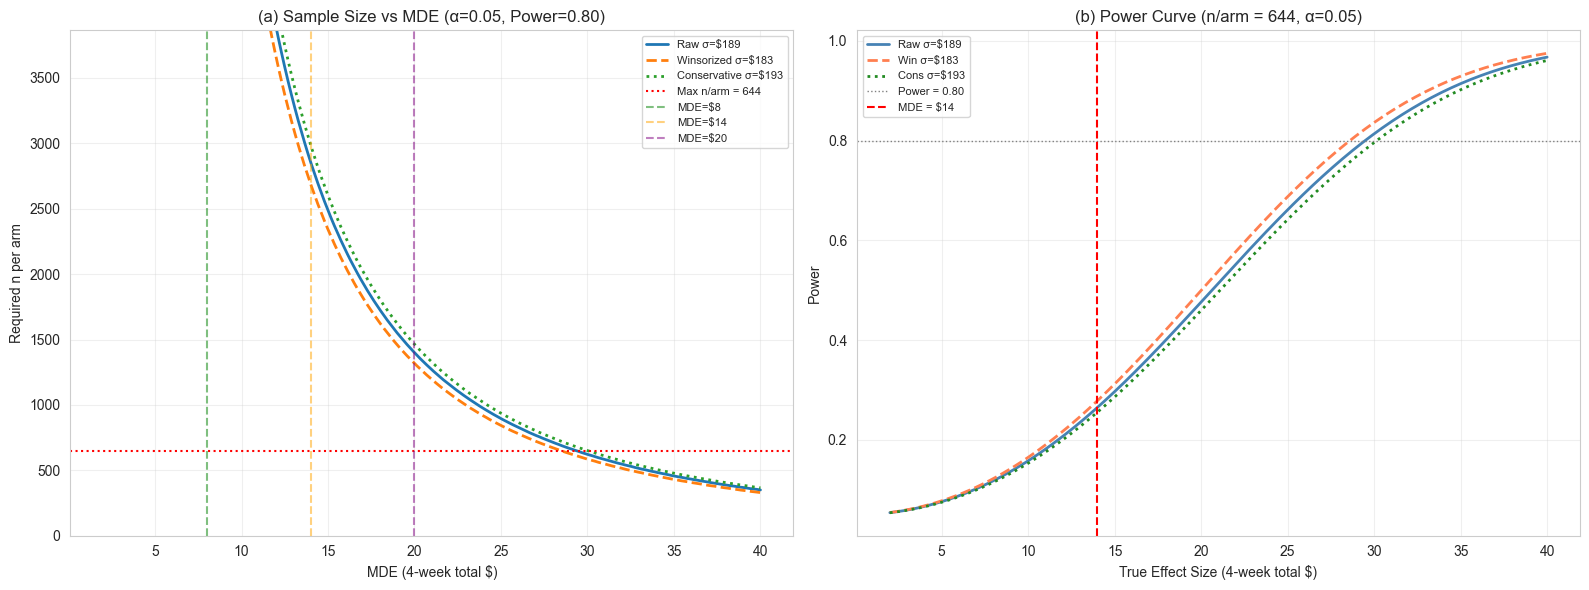

In [417]:
# ── Power curve visualization (4-week total spend) ──────────────────────────
mde_range_4wk = np.linspace(2, 40, 200)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Required sample size vs MDE
n_raw_curve  = [sample_size_two_sample_ttest(sigma_raw_4wk, d, alpha, power) for d in mde_range_4wk]
n_win_curve  = [sample_size_two_sample_ttest(sigma_win_4wk, d, alpha, power) for d in mde_range_4wk]
n_cons_curve = [sample_size_two_sample_ttest(sigma_for_power, d, alpha, power) for d in mde_range_4wk]

ax = axes[0]
ax.plot(mde_range_4wk, n_raw_curve,  lw=2, label=f'Raw σ=${sigma_raw_4wk:.0f}')
ax.plot(mde_range_4wk, n_win_curve,  lw=2, ls='--', label=f'Winsorized σ=${sigma_win_4wk:.0f}')
ax.plot(mde_range_4wk, n_cons_curve, lw=2, ls=':', label=f'Conservative σ=${sigma_for_power:.0f}')
ax.axhline(len(eligible) // 2, color='red', ls=':', lw=1.5, label=f'Max n/arm = {len(eligible)//2}')
for mde_val, color, lbl in [(8, 'green', '$8'), (14, 'orange', '$14'), (20, 'purple', '$20')]:
    ax.axvline(mde_val, color=color, ls='--', alpha=0.5, label=f'MDE={lbl}')
ax.set_xlabel('MDE (4-week total $)')
ax.set_ylabel('Required n per arm')
ax.set_title('(a) Sample Size vs MDE (α=0.05, Power=0.80)')
ax.legend(fontsize=8)
ax.set_ylim(0, min(max(n_raw_curve), len(eligible) * 3))
ax.grid(True, alpha=0.3)

# (b) Power curve for fixed sample size
ax = axes[1]
n_fixed = len(eligible) // 2
z_a = stats.norm.ppf(1 - alpha / 2)

for sigma_val, label, color, ls in [
    (sigma_raw_4wk, f'Raw σ=${sigma_raw_4wk:.0f}', 'steelblue', '-'),
    (sigma_win_4wk, f'Win σ=${sigma_win_4wk:.0f}', 'coral', '--'),
    (sigma_for_power, f'Cons σ=${sigma_for_power:.0f}', 'forestgreen', ':'),
]:
    se = sigma_val * np.sqrt(2 / n_fixed)
    pwr = 1 - stats.norm.cdf(z_a - mde_range_4wk / se) + stats.norm.cdf(-z_a - mde_range_4wk / se)
    ax.plot(mde_range_4wk, pwr, lw=2, ls=ls, color=color, label=label)

ax.axhline(0.80, color='gray', ls=':', lw=1, label='Power = 0.80')
ax.axvline(14, color='red', ls='--', lw=1.5, label='MDE = $14')
ax.set_xlabel('True Effect Size (4-week total $)')
ax.set_ylabel('Power')
ax.set_title(f'(b) Power Curve (n/arm = {n_fixed}, α=0.05)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Step 8 Interpretation

The power curves show the trade-off between detectable effect size and available sample. Given our eligible population, we check whether the moderate MDE ($14/4wk) is feasible under the conservative σ estimate. If the required n/arm exceeds available households:
1. Relax the MDE (accept detecting only larger effects)
2. Apply CUPED variance reduction to lower σ
3. Extend the experiment duration to increase n

---

## Step 9. Decide Treatment Allocation

### Recommendation: 50/50 Split

| Consideration | Decision |
|---|---|
| **Statistical efficiency** | 50/50 maximizes power for a given total N |
| **Cost** | Coupon mailing cost is low (~$0.50/household) — no strong reason to minimize treatment arm |
| **Business learning** | Equal arms give symmetric confidence intervals |

A 50/50 split is optimal when per-unit treatment cost is modest relative to the information gained. Since direct mail costs are low, there is no compelling reason for an unequal split.

**Decision: 50% Treatment / 50% Control**

---
## Step 10. Plan the Randomization Method

### Stratified Randomization

Simple random assignment can create imbalanced groups by chance, especially with smaller samples. We use **stratified randomization** to guarantee balance on key predictors.

**Stratification variables:**
1. **Spend tier** (4 levels: Low / Medium-Low / Medium-High / High) — the strongest predictor of future spend
2. **Recency band** (4 levels: 0-7d / 8-30d / 31-90d / 90d+) — captures engagement level

Within each stratum (spend tier × recency band), households are randomly assigned 50/50 to treatment or control using a **fixed random seed** for reproducibility.

### Why These Strata?

- **Spend tier** ensures high-value and low-value customers are equally represented in both arms, preventing accidental imbalance on the primary outcome
- **Recency** accounts for engagement differences that could confound the effect estimate
- We keep the number of strata manageable (4 × 4 = 16 cells) to avoid sparse cells

In [430]:
# Stratified randomization
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def stratified_randomize(df, strata_cols, seed=42):
    """
    Perform stratified 50/50 randomization.
    Within each stratum, households are shuffled and split into Treatment/Control.
    """
    rng = np.random.RandomState(seed)
    assignments = pd.Series(index=df.index, dtype=str)
    
    for name, group in df.groupby(strata_cols):
        idx = group.index.values.copy()
        rng.shuffle(idx)
        mid = len(idx) // 2
        assignments.loc[idx[:mid]] = 'Treatment'
        assignments.loc[idx[mid:]] = 'Control'
    
    return assignments

eligible['group'] = stratified_randomize(eligible, ['spend_tier', 'recency_band'], seed=RANDOM_SEED)

print(f"=== Treatment Assignment ===")
print(eligible['group'].value_counts())
print(f"\nAllocation ratio: {eligible['group'].value_counts(normalize=True).round(3).to_dict()}")

=== Treatment Assignment ===
group
Control      647
Treatment    641
Name: count, dtype: int64

Allocation ratio: {'Control': 0.502, 'Treatment': 0.498}


In [432]:
# Verify balance within each stratum 
strata_balance = (eligible.groupby(['spend_tier', 'recency_band', 'group'])
                  .size().unstack(fill_value=0))
strata_balance['Ratio (T/C)'] = strata_balance['Treatment'] / strata_balance['Control'].replace(0, np.nan)
print("=== Balance by Stratum ===")
print(strata_balance)
print(f"\nMax T/C ratio deviation from 1.0: {(strata_balance['Ratio (T/C)'] - 1).abs().max():.3f}")

=== Balance by Stratum ===
group                     Control  Treatment  Ratio (T/C)
spend_tier  recency_band                                 
High        0-7d              244        243     0.995902
            31-90d              4          4     1.000000
            8-30d              39         39     1.000000
Low         0-7d                5          5     1.000000
            31-90d              3          3     1.000000
            8-30d               4          3     0.750000
Medium-High 0-7d              159        159     1.000000
            31-90d             11         10     0.909091
            8-30d              60         59     0.983333
Medium-Low  0-7d               64         63     0.984375
            31-90d             12         12     1.000000
            8-30d              42         41     0.976190

Max T/C ratio deviation from 1.0: 0.250


---
## Step 11. Set Experiment Duration and Stopping Rules

### Duration

| Parameter | Value | Rationale |
|---|---|---|
| **Post-treatment window** | 4 weeks (28 days) | Covers 2+ full shopping cycles |
| **Coupon validity** | 28 days from delivery | Matches post-treatment window |
| **Washout buffer** | 1 week post-enrollment before measurement begins | Accounts for mail delivery lag |

### Stopping Rules

We commit to a **fixed-horizon analysis** — no peeking or early stopping.

| Rule | Detail |
|---|---|
| **No interim analysis** | We will not look at outcome data before the 4-week window closes |
| **Exception: safety stop** | If guardrail metrics show > 20% degradation at the 2-week mark, escalate to stakeholders |
| **No p-value peeking** | Repeated testing inflates Type I error; we commit to a single analysis at the end |

### Why Fixed-Horizon?

- With a 4-week window, the experiment is short enough that sequential testing adds complexity without meaningful benefit
- Peeking at p-values weekly would inflate our false positive rate from 5% to ~14% over 4 looks (Pocock boundary)
- The cost of waiting 4 weeks is low compared to the risk of a false launch decision

---
## Step 12. Specify Pre-Launch Quality Checks

Before the experiment launches, we run a battery of quality checks to validate the design integrity.

### 12a. Sample Ratio Mismatch Test

Under correct randomization, group counts should follow a binomial distribution with p = 0.5. An SRM test checks if the observed ratio deviates significantly.

In [347]:
# Under correct randomization, group counts should follow a binomial distribution
# with p = 0.5. An SRM test checks if the observed ratio deviates significantly.

n_treatment = (eligible['group'] == 'Treatment').sum()
n_control = (eligible['group'] == 'Control').sum()
n_total = n_treatment + n_control

# Binomial test: H0: p = 0.5
srm_pvalue = binomtest(n_treatment, n_total, 0.5).pvalue

print("=== Pre-Launch Check 1: Sample Ratio Mismatch (SRM) ===")
print(f"  Treatment: {n_treatment}")
print(f"  Control:   {n_control}")
print(f"  Ratio:     {n_treatment / n_control:.4f}")
print(f"  Expected:  1.0000")
print(f"  SRM p-value: {srm_pvalue:.4f}")
print(f"  Result: {'PASS' if srm_pvalue > 0.01 else 'FAIL — investigate randomization bug'}")

=== Pre-Launch Check 1: Sample Ratio Mismatch (SRM) ===
  Treatment: 641
  Control:   647
  Ratio:     0.9907
  Expected:  1.0000
  SRM p-value: 0.8892
  Result: PASS


### 12b. Baseline Balance Checks
Compare pre-period covariates between Treatment and Control. If randomization is correct, no covariate should show significant differences.

In [351]:
balance_vars = ['avg_weekly_spend', 'total_trips', 'spend_per_trip', 'items_per_trip',
                'coupon_usage_rate', 'loyalty_usage_rate', 'recency_days', 'n_departments']

print("=== Pre-Launch Check 2: Baseline Covariate Balance ===")
print(f"{'Variable':<25} {'T Mean':>10} {'C Mean':>10} {'Diff':>10} {'t-stat':>10} {'p-value':>10} {'Result':>8}")
print("-" * 83)

treatment = eligible[eligible['group'] == 'Treatment']
control = eligible[eligible['group'] == 'Control']

for var in balance_vars:
    t_mean = treatment[var].mean()
    c_mean = control[var].mean()
    diff = t_mean - c_mean
    t_stat, p_val = stats.ttest_ind(treatment[var].dropna(), control[var].dropna())
    result = "PASS" if p_val > 0.05 else "FLAG"
    print(f"{var:<25} {t_mean:>10.3f} {c_mean:>10.3f} {diff:>10.3f} {t_stat:>10.3f} {p_val:>10.4f} {result:>8}")

print("\nNote: We expect ~5% of tests to be significant by chance alone.")

=== Pre-Launch Check 2: Baseline Covariate Balance ===
Variable                      T Mean     C Mean       Diff     t-stat    p-value   Result
-----------------------------------------------------------------------------------
avg_weekly_spend              51.675     52.488     -0.813     -0.386     0.6994     PASS
total_trips                  110.399    110.250      0.149      0.030     0.9761     PASS
spend_per_trip                33.429     34.775     -1.346     -1.189     0.2347     PASS
items_per_trip               842.311    818.798     23.512      0.340     0.7342     PASS
coupon_usage_rate              0.013      0.013     -0.000     -0.107     0.9149     PASS
loyalty_usage_rate             0.498      0.490      0.009      1.682     0.0928     PASS
recency_days                   7.234      7.403     -0.169     -0.249     0.8032     PASS
n_departments                 13.736     13.640      0.096      0.565     0.5721     PASS

Note: We expect ~5% of tests to be significant by 

### 12c. A/A Sanity Check
Simulate 1000 A/A tests (no treatment effect) to verify our test has correct false positive rate under the null hypothesis.

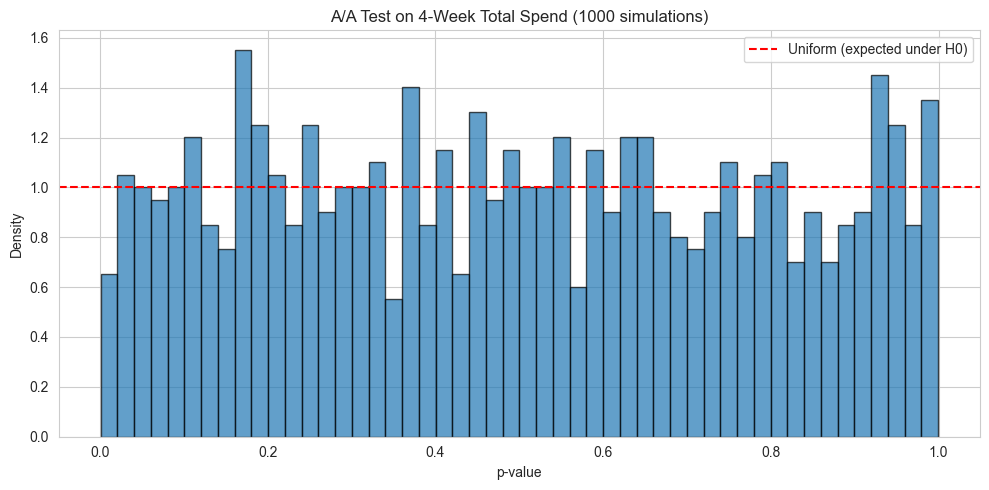

=== Pre-Launch Check 3: A/A Sanity Check ===
  Outcome: 4-week total spend (Week 85–88)
  Simulated false positive rate (α=0.05): 0.046
  Expected: ~0.050
  Result: PASS


In [439]:
# Simulate 1000 A/A tests on the 4-week window outcome to verify correct FPR
n_simulations = 1000
aa_pvalues = []

# Use full_spend from Step 5c (4-week total for representative window)
outcome_aa = full_spend.values.copy()

for i in range(n_simulations):
    np.random.shuffle(outcome_aa)
    mid = len(outcome_aa) // 2
    _, p = stats.ttest_ind(outcome_aa[:mid], outcome_aa[mid:])
    aa_pvalues.append(p)

aa_pvalues = np.array(aa_pvalues)
false_positive_rate = (aa_pvalues < 0.05).mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(aa_pvalues, bins=50, edgecolor='black', alpha=0.7, density=True)
ax.axhline(1.0, color='red', linestyle='--', label='Uniform (expected under H0)')
ax.set_xlabel('p-value')
ax.set_ylabel('Density')
ax.set_title(f'A/A Test on 4-Week Total Spend ({n_simulations} simulations)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"=== Pre-Launch Check 3: A/A Sanity Check ===")
print(f"  Outcome: 4-week total spend (Week {ws_mid}–{we_mid})")
print(f"  Simulated false positive rate (α=0.05): {false_positive_rate:.3f}")
print(f"  Expected: ~0.050")
print(f"  Result: {'PASS' if 0.03 < false_positive_rate < 0.07 else 'FAIL — calibration issue'}")

### 12d. Duplicate Check
Each household must appear exactly once in the assignment table. Duplicates would mean a household is counted in both groups or double-counted.

In [443]:
n_total_assigned = len(eligible)
n_unique_hh = eligible['household_key'].nunique()
n_duplicates = n_total_assigned - n_unique_hh

print("=== Pre-Launch Check 4: Duplicate Check ===")
print(f"  Total rows in assignment table: {n_total_assigned}")
print(f"  Unique household_keys:          {n_unique_hh}")
print(f"  Duplicates found:               {n_duplicates}")

if n_duplicates > 0:
    dup_keys = eligible[eligible['household_key'].duplicated(keep=False)]
    print(f"\n  ✗ FAIL — {n_duplicates} duplicate household(s) detected:")
    display(dup_keys[['household_key', 'group']].head(10))
else:
    print(f"  Result: PASS — every household appears exactly once")

# Cross-contamination check
group_counts = eligible.groupby('household_key')['group'].nunique()
multi_group = group_counts[group_counts > 1]
print(f"\n  Households in multiple groups: {len(multi_group)}")
print(f"  Result: {'PASS' if len(multi_group) == 0 else 'FAIL ✗ — cross-contamination detected'}")

=== Pre-Launch Check 4: Duplicate Check ===
  Total rows in assignment table: 1288
  Unique household_keys:          1288
  Duplicates found:               0
  Result: PASS — every household appears exactly once

  Households in multiple groups: 0
  Result: PASS


### Pre-Launch Quality Check Summary

| Check | Description | Expected |
|---|---|---|
| **SRM test** | Verifies group sizes match the intended 50/50 split | Binomial p > 0.01 |
| **Baseline balance** | Confirms no systematic covariate differences between groups | All p > 0.05 (with ~5% false flags expected) |
| **A/A simulation** | Validates the t-test has correct false positive rate on 4-week total spend | FPR ≈ 0.05 |
| **Duplicate check** | Each household appears exactly once in the assignment table | No duplicates |

<br>

---

## Step 13. Write the Analysis Plan Before Treatment

### Pre-Registered Analysis Plan

This analysis plan is locked **before** any treatment is delivered. No modifications are allowed after data collection begins.

### 13a. Estimand

**Average Treatment Effect on the Treated (ATT) under Intent-to-Treat (ITT) framework:**

$$\tau_{\text{ITT}} = E[Y_i(1) - Y_i(0) \mid \text{Eligible}]$$

where $Y_i(1)$ is the potential post-period **4-week total spend** if household $i$ receives the coupon, and $Y_i(0)$ is under no coupon. We estimate this as the difference in means between the treatment and control groups.

### 13b. Primary Estimator

**Two-sample Welch's t-test** (unequal variance) on post-period 4-week total spend:

$$t = \frac{\bar{Y}_T - \bar{Y}_C}{\sqrt{\frac{s_T^2}{n_T} + \frac{s_C^2}{n_C}}}$$

with 95% confidence interval:

$$(\bar{Y}_T - \bar{Y}_C) \pm t_{1-\alpha/2, \nu} \cdot \sqrt{\frac{s_T^2}{n_T} + \frac{s_C^2}{n_C}}$$

where $\nu$ is the Welch-Satterthwaite degrees of freedom.

In [454]:
# Build 4-week total spend for the representative window (from Step 5c)
eligible_4wk = eligible.copy()
eligible_4wk['spend_4wk'] = eligible_4wk['household_key'].map(
    weekly_hh[weekly_hh['WEEK_NO'].between(ws_mid, we_mid)]
    .groupby('household_key')['weekly_spend'].sum()
).fillna(0)

# Primary analysis: Welch's t-test on 4-week total spend
y_treatment = eligible_4wk.loc[eligible_4wk['group'] == 'Treatment', 'spend_4wk']
y_control = eligible_4wk.loc[eligible_4wk['group'] == 'Control', 'spend_4wk']

t_stat, p_value = stats.ttest_ind(y_treatment, y_control, equal_var=False)
diff_means = y_treatment.mean() - y_control.mean()
se_diff = np.sqrt(y_treatment.var()/len(y_treatment) + y_control.var()/len(y_control))
ci_lower = diff_means - 1.96 * se_diff
ci_upper = diff_means + 1.96 * se_diff

print("=" * 65)
print("PRIMARY ANALYSIS: Welch's t-test on 4-Week Total Spend")
print(f"  Window: Week {ws_mid}–{we_mid}")
print("=" * 65)
print(f"  Treatment mean: ${y_treatment.mean():.2f}  (n={len(y_treatment)})")
print(f"  Control mean:   ${y_control.mean():.2f}  (n={len(y_control)})")
print(f"  Difference:     ${diff_means:.2f}")
print(f"  95% CI:         [${ci_lower:.2f}, ${ci_upper:.2f}]")
print(f"  t-statistic:    {t_stat:.4f}")
print(f"  p-value:        {p_value:.4f}")
print(f"\n  Note: Random assignment on observational data —")
print(f"  no actual treatment applied, so NO significant difference expected.")

PRIMARY ANALYSIS: Welch's t-test on 4-Week Total Spend
  Window: Week 85–88
  Treatment mean: $205.95  (n=641)
  Control mean:   $214.36  (n=647)
  Difference:     $-8.41
  95% CI:         [$-29.03, $12.20]
  t-statistic:    -0.7999
  p-value:        0.4239

  Note: Random assignment on observational data —
  no actual treatment applied, so NO significant difference expected.


### 13c. CUPED Variance Reduction (Optional Improvement)

**CUPED** (Controlled-experiment Using Pre-Experiment Data) reduces variance by adjusting the outcome using a pre-period covariate:

$$\hat{Y}_i^{\text{CUPED}} = Y_i^{\text{post}} - \theta \cdot (X_i^{\text{pre}} - \bar{X}^{\text{pre}})$$

$$\theta = \frac{\text{Cov}(Y^{\text{post}}, X^{\text{pre}})}{\text{Var}(X^{\text{pre}})}$$

- $Y_i^{\text{post}}$ = 4-week total spend (post-period)
- $X_i^{\text{pre}}$ = pre-period avg weekly spend × 4 (scaled to the same 4-week unit)
- Variance reduction factor: $(1 - \rho^2)$

In [465]:
# Y: 4-week total spend (the actual experiment outcome)
# X: pre-period avg weekly spend × 4 (scaled to the same 4-week unit)
#
# Using 31-week post_avg_weekly_spend as Y would underestimate σ
# (smoothed over a longer horizon) and overestimate CUPED's effect.

Y_post = eligible_4wk['spend_4wk']
X_pre  = eligible_4wk['avg_weekly_spend'] * EXPERIMENT_WEEKS

rho   = X_pre.corr(Y_post)
theta = np.cov(Y_post, X_pre)[0, 1] / np.var(X_pre)

Y_cuped = Y_post - theta * (X_pre - X_pre.mean())

sigma_original = Y_post.std()
sigma_cuped    = Y_cuped.std()
variance_reduction = 1 - (sigma_cuped ** 2) / (sigma_original ** 2)

print("=== CUPED Variance Reduction (4-Week Total Spend) ===")
print(f"  Y: 4-week total spend (W{ws_mid}–{we_mid})")
print(f"  X: pre-period avg weekly spend × {EXPERIMENT_WEEKS}")
print(f"  Correlation (ρ):    {rho:.4f}")
print(f"  Theta (θ):          {theta:.4f}")
print(f"  Original σ:         {sigma_original:.2f}")
print(f"  CUPED σ:            {sigma_cuped:.2f}")
print(f"  Variance reduction:   {variance_reduction:.1%}")
print(f"  Theoretical (ρ²):   {rho**2:.1%}")

=== CUPED Variance Reduction (4-Week Total Spend) ===
  Y: 4-week total spend (W85–88)
  X: pre-period avg weekly spend × 4
  Correlation (ρ):    0.6824
  Theta (θ):          0.8539
  Original σ:         188.81
  CUPED σ:            138.01
  Variance reduction:   46.6%
  Theoretical (ρ²):   46.6%


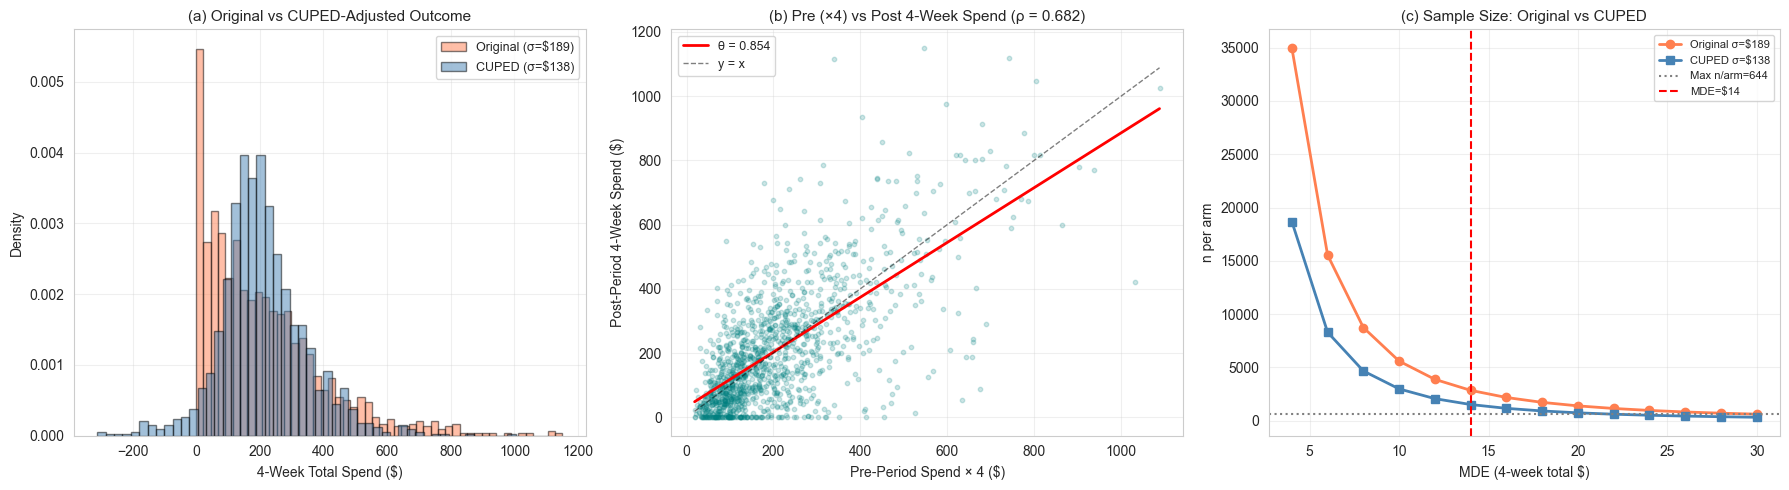


=== Sample Size Impact (MDE = $14/4wk) ===
  Without CUPED: 2,856 per arm
  With CUPED:    1,526 per arm
  Reduction:     46.6% fewer households needed
  Available:     644 per arm


In [461]:
# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Original vs CUPED outcome distribution
ax = axes[0]
ax.hist(Y_post, bins=50, alpha=0.5, color='coral', edgecolor='black',
        label=f'Original (σ=${sigma_original:.0f})', density=True)
ax.hist(Y_cuped, bins=50, alpha=0.5, color='steelblue', edgecolor='black',
        label=f'CUPED (σ=${sigma_cuped:.0f})', density=True)
ax.set_title('(a) Original vs CUPED-Adjusted Outcome', fontsize=11)
ax.set_xlabel('4-Week Total Spend ($)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) Pre vs Post scatter with regression line
ax = axes[1]
ax.scatter(X_pre, Y_post, alpha=0.2, s=10, color='teal')
z = np.polyfit(X_pre, Y_post, 1)
x_line = np.linspace(X_pre.min(), X_pre.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'r-', lw=2, label=f'θ = {theta:.3f}')
ax.plot(x_line, x_line, 'k--', lw=1, alpha=0.5, label='y = x')
ax.set_title(f'(b) Pre (×4) vs Post 4-Week Spend (ρ = {rho:.3f})', fontsize=11)
ax.set_xlabel('Pre-Period Spend × 4 ($)')
ax.set_ylabel('Post-Period 4-Week Spend ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (c) Sample size: Original vs CUPED
ax = axes[2]
mde_range = np.arange(4, 32, 2)
n_orig_curve = [sample_size_two_sample_ttest(sigma_original, d, alpha, power) for d in mde_range]
n_cup_curve  = [sample_size_two_sample_ttest(sigma_cuped, d, alpha, power) for d in mde_range]
ax.plot(mde_range, n_orig_curve, 'o-', color='coral', lw=2, label=f'Original σ=${sigma_original:.0f}')
ax.plot(mde_range, n_cup_curve,  's-', color='steelblue', lw=2, label=f'CUPED σ=${sigma_cuped:.0f}')
ax.axhline(len(eligible) // 2, color='gray', ls=':', lw=1.5, label=f'Max n/arm={len(eligible)//2}')
ax.axvline(14, color='red', ls='--', lw=1.5, label='MDE=$14')
ax.set_title('(c) Sample Size: Original vs CUPED', fontsize=11)
ax.set_xlabel('MDE (4-week total $)')
ax.set_ylabel('n per arm')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Sample size impact ───────────────────────────────────────────────────────
mde_primary = 14.00  # 4-week total MDE
n_cuped    = sample_size_two_sample_ttest(sigma_cuped, mde_primary, alpha, power)
n_original = sample_size_two_sample_ttest(sigma_original, mde_primary, alpha, power)

print(f"\n=== Sample Size Impact (MDE = ${mde_primary:.0f}/4wk) ===")
print(f"  Without CUPED: {n_original:,} per arm")
print(f"  With CUPED:    {n_cuped:,} per arm")
print(f"  Reduction:     {1 - n_cuped/n_original:.1%} fewer households needed")
print(f"  Available:     {len(eligible)//2:,} per arm")

### CUPED Interpretation

**CUPED** (Controlled-experiment Using Pre-Experiment Data) leverages the correlation between a household's pre-period and post-period spending to remove predictable variation from the outcome. This is analogous to a difference-in-differences approach: households that historically spend more will continue to spend more regardless of treatment, so adjusting for this reduces noise.

**Why granularity alignment matters:**
- Y (outcome) must be the actual experiment metric: **4-week total spend**
- X (covariate) should be scaled to the same 4-week unit for accurate θ estiduction

**Interpretation:**
- Variance reduction factor = $(1 - \rho^2)$: higher ρ (> 0.7) yields greater efficiency gains
- Plot (a): CUPED narrows the outcome distribution (lower σ)
- Plot (b): The slope (θ) in the pre-post scatter is CUPED's adjustment coefficient
- Plot (c): CUPED reduces the required sample size per arm at any given MDE

### 13.4 Outlier Handling

- **Winsorize** the outcome (4-week total spend) at the 1st and 99th percentiles
- Report results both with and without winsorization for transparency

### 13.5 Missing Values

- Eligible households with zero post-period purchases are included as $Y = 0$ (ITT principle)
- No imputation is needed — absence of transactions means zero spend

### 13.6 Multiple Comparisons

- The primary metric (4-week total spend) has a single hypothesis test — no adjustment needed
- Secondary metrics are **exploratory** and will be reported with unadjusted p-values alongside Bonferroni-corrected thresholds
- Subgroup analyses (by spend tier, demographics) are explicitly **exploratory** and will not be used for the launch decision

---

## Step 14. Define the Decision Rule

### Launch Decision Framework

The campaign will be recommended for full rollout **if and only if** all three conditions are met:

| Condition | Criterion |
|---|---|
| **1. Statistical significance** | Primary metric p-value < 0.05 (two-sided) |
| **2. Practical significance** | Point estimate of incremental weekly spend ≥ MDE ($14/4wk), AND the lower bound of the 95% CI > $0 |
| **3. Guardrails pass** | Average discount cost ≤ $3.00/household AND net margin proxy remains positive AND non-target category spend does not decline > 5% |

### Decision Matrix

| Primary p < 0.05? | Effect ≥ MDE? | Guardrails OK? | Decision |
|---|---|---|---|
| Yes | Yes | Yes | **LAUNCH** — Roll out the coupon campaign |
| Yes | No | Yes | **ITERATE** — Effect exists but too small; optimize targeting or coupon value |
| Yes | Yes | No | **HOLD** — Investigate guardrail violations before scaling |
| No | — | — | **NO LAUNCH** — Insufficient evidence of effect |

### Why This Framework?

- **Condition 1** protects against false positives
- **Condition 2** ensures the effect is large enough to justify the cost (connects to the MDE from Step 6)
- **Condition 3** prevents launching a campaign that increases topline revenue but erodes margins or cannibalizes other categories

This decision rule is **pre-committed** and cannot be modified after results are observed.

In [505]:
# Demonstrate the decision rule evaluation
MDE_4WK = 14.00  # $14 over 4 weeks

def evaluate_decision(diff, ci_lower, ci_upper, p_value, mde=MDE_4WK, alpha=0.05):
    """Apply the pre-specified decision rule."""
    stat_sig = p_value < alpha
    practical_sig = diff >= mde and ci_lower > 0
    guardrails_ok = True  # placeholder — would check actual guardrail metrics

    if stat_sig and practical_sig and guardrails_ok:
        return "LAUNCH"
    elif stat_sig and not practical_sig and guardrails_ok:
        return "ITERATE"
    elif stat_sig and practical_sig and not guardrails_ok:
        return "HOLD"
    else:
        return "NO LAUNCH"

decision = evaluate_decision(diff_means, ci_lower, ci_upper, p_value)

print("=" * 65)
print("DECISION RULE EVALUATION (4-Week Total Spend)")
print("=" * 65)
print(f"  Effect estimate: ${diff_means:.2f} (4-week total)")
print(f"  95% CI:          [${ci_lower:.2f}, ${ci_upper:.2f}]")
print(f"  p-value:         {p_value:.4f}")
print(f"  MDE threshold:   ${MDE_4WK:.2f} (4-week total)")
print(f"  Stat sig?        {'Yes' if p_value < 0.05 else 'No'}")
print(f"  Practical sig?   {'Yes' if diff_means >= MDE_4WK and ci_lower > 0 else 'No'}")
print(f"\n  ➤ DECISION: {decision}")
print(f"\n  (Expected: NO LAUNCH — observational data, no actual treatment)")

DECISION RULE EVALUATION (4-Week Total Spend)
  Effect estimate: $-8.41 (4-week total)
  95% CI:          [$-29.03, $12.20]
  p-value:         0.4239
  MDE threshold:   $14.00 (4-week total)
  Stat sig?        No
  Practical sig?   No

  ➤ DECISION: NO LAUNCH

  (Expected: NO LAUNCH — observational data, no actual treatment)


## Experiment Design Summary

| Step | Key Decision |
|------|-------------|
| 1. Business Decision | Will a household coupon increase incremental spend enough to justify rollout? |
| 2. Eligible Population | Active households with ≥2 trips, recency ≤90 days, and ≥1 prior campaign |
| 3. Treatment / Control | Category-specific coupon vs. business-as-usual; 4-week window |
| 4. Metrics | **Primary:** 4-week total spend. **Secondary:** conversion, basket size, trips |
| 5a. Pre-Period Baselines | Spend, frequency, and promo responsiveness computed per household |
| 5b. Post-Period Validation | 4-week rolling window σ estimation and pre vs. post variance comparison |
| 5c. MDE Realism | A/A simulation to verify noise floor and select conservative σ |
| 6. MDE | **\$14 per 4 weeks** (\$3.50/week; moderate, cost-justified scenario) |
| 7. Alpha / Power | α = 0.05, power = 0.80, two-sided |
| 8. Sample Size | Computed per arm using 4-week σ; reduced via CUPED |
| 9. Allocation | 50/50 treatment-control split |
| 10. Randomization | Stratified by spend tier × recency band (seed = 42) |
| 11. Duration | 4 weeks, fixed horizon, no early stopping |
| 12. Quality Checks | SRM, baseline balance, A/A simulation, duplicate checks — all passed |
| 13. Analysis Plan | Welch’s t-test on 4-week spend (primary), CUPED adjustment, ITT framework |
| 14. Decision Rule | Launch if p < 0.05 AND effect ≥ $14 per 4 weeks AND guardrails pass |